# Concise Vehicle Sales CSV Export & Matplotlib Pipeline
This notebook contains a clean, optimized, and heavily commented implementation of the data cleaning, CSV export, and Python-based analytics pipeline. 

### **What we did in this version:**
1. **Concised Code:** Combined redundant code, simplified cleaning loops, and reduced script length while maintaining exactly the same functionality.
2. **Removed Pandas & NumPy:** Relies solely on Python's built-in standard libraries (`csv`, `datetime`) for lightweight data processing.
3. **Cleaned CSV Output:** Cleans 2lac (200,000) data records from the raw dataset and exports it to a structured CSV file in the `clean_data` directory.
4. **Added Data Visualizations (Matplotlib):** Reads query results directly from the exported CSV file into standard Python structures and plots visual charts with `matplotlib.pyplot` without any pandas overhead.
5. **Explanatory Comments:** Added line-by-line comments detailing every operation.

### **Dependencies Installation**
Run this cell to install `tabulate` and `matplotlib` if they are missing from your environment.

In [8]:
# !pip install tabulate matplotlib

## 1. Environment Setup & Output Directory Verification
Here, we initialize configuration settings, define our raw dataset path, and build the target output directory.

In [9]:
import os
import csv
import datetime
from tabulate import tabulate
import matplotlib.pyplot as plt

# CSV configuration settings
CSV_FILE_PATH = os.path.join("data", "car_prices.csv")
CLEAN_DATA_DIR = os.path.join("clean_data")
CLEAN_CSV_PATH = os.path.join(CLEAN_DATA_DIR, "cleaned_car_prices2.csv")
MAX_ROWS = int(input("Enter the maximum number of rows to Clean: ") or 500000)  # Default to 200000 rows

def setup_clean_directory():
    """Creates the target clean_data directory if it does not exist."""
    os.makedirs(CLEAN_DATA_DIR, exist_ok=True)
    print(f"[+] Output directory '{CLEAN_DATA_DIR}' verified.")

setup_clean_directory()

[+] Output directory 'clean_data' verified.


## 2. Concise Date Parsing & Data Cleaning Rules
We define the parsing and validation rules using only pure Python to scrub, title-case, check ranges, and prepare cells for insertion.

In [10]:
def parse_saledate(date_str):
    """Parses standard raw date formats including timezone offsets like GMT-0800 (PST)."""
    if not date_str:
        return None
    
    # Standardize GMT-0800 strings (e.g. "Tue Dec 16 2014 12:30:00 GMT-0800")
    parts = date_str.strip().split()
    if len(parts) >= 5:
        try:
            return datetime.datetime.strptime(f"{parts[1]} {parts[2]} {parts[3]} {parts[4]}", "%b %d %Y %H:%M:%S")
        except ValueError:
            pass
            
    # Fallback checks for ISO, slashed, or short date formats
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%m/%d/%Y %H:%M", "%m/%d/%Y"):
        try:
            return datetime.datetime.strptime(date_str.strip(), fmt)
        except ValueError:
            continue
    return None

def clean_row(row):
    """Validates schema restrictions and cleans a single data row. Returns dict or None."""
    # Match missing cell values and standard placeholders
    placeholders = {'', '—', 'null', 'nan', 'none', 'n/a', 'na', '-', 'undefined'}
    
    # Ensure all columns have valid filled contents
    for key, val in row.items():
        if val is None or str(val).strip().lower() in placeholders:
            return None
            
    try:
        cleaned = {}
        
        # 1. Validate manufacturing year constraints
        year = int(row['year'].strip())
        if year < 1900 or year > datetime.datetime.now().year + 2:
            return None
        cleaned['year'] = year
        
        # 2. Standardize text casings
        cleaned['make'] = row['make'].strip().title()
        cleaned['model'] = row['model'].strip().title()
        cleaned['trim'] = row['trim'].strip()
        cleaned['body'] = row['body'].strip().title()
        cleaned['color'] = row['color'].strip().title()
        cleaned['interior'] = row['interior'].strip().title()
        cleaned['seller'] = row['seller'].strip()
        cleaned['state'] = row['state'].strip().upper()
        
        # 3. Handle transmission groups
        trans = row['transmission'].strip().lower()
        if 'auto' in trans:
            cleaned['transmission'] = 'automatic'
        elif 'man' in trans:
            cleaned['transmission'] = 'manual'
        else:
            return None
            
        # 4. Check VIN requirements
        vin = row['vin'].strip().upper()
        if len(vin) < 5 or not vin.isalnum():
            return None
        cleaned['vin'] = vin
        
        # 5. Parse numerical fields (non-negative)
        cond = float(row['condition'].strip())
        odo = int(row['odometer'].strip())
        mmr = int(row['mmr'].strip())
        sp = int(row['sellingprice'].strip())
        
        if cond < 0 or cond > 50 or odo < 0 or mmr < 0 or sp < 0:
            return None
            
        cleaned.update({'condition': cond, 'odometer': odo, 'mmr': mmr, 'sellingprice': sp})
        
        # 6. Parse and derive date parameters
        dt = parse_saledate(row['saledate'])
        if not dt:
            return None
        cleaned['saledate_obj'] = dt
        cleaned['saledate'] = dt.strftime("%Y-%m-%d")
        cleaned['saleday'] = dt.strftime("%A")
        
        return cleaned
    except (ValueError, KeyError, TypeError):
        return None

## 3. Data Ingestion & CSV Export Pipeline
Reads, cleans, chronologically sorts, and batch-exports the records into a clean CSV file.

In [11]:
def ingest_csv_data():
    """Performs chronological sorting and exports cleaned records to a CSV file."""
    if not os.path.exists(CSV_FILE_PATH):
        print(f"[-] Ingestion stopped: File not found at {CSV_FILE_PATH}")
        return
        
    print("[*] Scanning and scrubbing raw CSV...")
    cleaned_records = []
    scanned, skipped = 0, 0
    
    # Open raw file and stream records one-by-one
    with open(CSV_FILE_PATH, mode='r', encoding='utf-8', errors='ignore') as f:
        for row in csv.DictReader(f):
            scanned += 1
            cleaned = clean_row(row)
            if cleaned:
                cleaned_records.append(cleaned)
                if len(cleaned_records) == MAX_ROWS:
                    break
            else:
                skipped += 1
                
    print(f"    - Processed rows: {scanned:,} | Collected: {len(cleaned_records):,} | Skipped: {skipped:,}")
    
    # Sort data chronologically using the datetime objects
    print("[*] Sorting records chronologically by sale date...")
    cleaned_records.sort(key=lambda x: x['saledate_obj'])
    
    # Define fields to write (excluding the datetime object used for sorting)
    fieldnames = [
        'year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 
        'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 
        'sellingprice', 'saledate', 'saleday'
    ]
    
    print(f"[*] Exporting cleaned records to CSV: {CLEAN_CSV_PATH}...")
    try:
        with open(CLEAN_CSV_PATH, mode='w', encoding='utf-8', newline='') as f_out:
            writer = csv.DictWriter(f_out, fieldnames=fieldnames, extrasaction='ignore')
            writer.writeheader()
            for r in cleaned_records:
                writer.writerow(r)
        print(f"[+] CSV Export Complete! Successfully wrote {len(cleaned_records):,} records.")
    except Exception as e:
        print(f"[-] CSV write failed: {e}")

ingest_csv_data()

[*] Scanning and scrubbing raw CSV...
    - Processed rows: 558,837 | Collected: 440,393 | Skipped: 118,444
[*] Sorting records chronologically by sale date...
[*] Exporting cleaned records to CSV: clean_data\cleaned_car_prices2.csv...
[+] CSV Export Complete! Successfully wrote 440,393 records.


## 4. Verification and Data Quality Checks
We load the exported CSV file back into Python to inspect the data shape, verify duplicate VIN counts, and preview the records.

In [12]:
def load_cleaned_data():
    """Utility to load the cleaned CSV file into a list of dictionaries with correct types."""
    records = []
    if not os.path.exists(CLEAN_CSV_PATH):
        print(f"[-] Error: File not found at {CLEAN_CSV_PATH}")
        return records
        
    with open(CLEAN_CSV_PATH, mode='r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            # Parse numerical fields back to correct types
            row['year'] = int(row['year'])
            row['condition'] = float(row['condition'])
            row['odometer'] = int(row['odometer'])
            row['mmr'] = int(row['mmr'])
            row['sellingprice'] = int(row['sellingprice'])
            records.append(row)
    return records

def verify_data_integrity():
    """Validates row counts, null values, and prints schema types using the cleaned CSV."""
    records = load_cleaned_data()
    if not records:
        return
        
    total_rows = len(records)
    print(f"[1] Cleaned CSV Records Count: {total_rows:,}")
    
    # Calculate duplicate VINs
    vins = [r['vin'] for r in records]
    duplicate_vins = len(vins) - len(set(vins))
    print(f"[2] Duplicate VIN Count: {duplicate_vins:,}")
    
    # Schema description matching CSV columns
    schema_info = [
        ['year', 'int', 'NO', ''],
        ['make', 'varchar(50)', 'NO', ''],
        ['model', 'varchar(100)', 'NO', ''],
        ['trim', 'varchar(100)', 'NO', ''],
        ['body', 'varchar(50)', 'NO', ''],
        ['transmission', 'varchar(20)', 'NO', ''],
        ['vin', 'varchar(50)', 'NO', 'MUL'],
        ['state', 'varchar(10)', 'NO', ''],
        ['condition', 'float', 'NO', ''],
        ['odometer', 'int', 'NO', ''],
        ['color', 'varchar(50)', 'NO', ''],
        ['interior', 'varchar(50)', 'NO', ''],
        ['seller', 'varchar(255)', 'NO', ''],
        ['mmr', 'int', 'NO', ''],
        ['sellingprice', 'int', 'NO', ''],
        ['saledate', 'date', 'NO', ''],
        ['saleday', 'varchar(20)', 'NO', '']
    ]
    print("\n[3] Exported CSV Schema Description:")
    print(tabulate(schema_info, headers=['Field', 'Type', 'Null', 'Key'], tablefmt='psql'))
    
    # Helper to construct table previews
    def get_table_rows(subset_records, start_id):
        table_rows = []
        for i, r in enumerate(subset_records):
            dt = datetime.datetime.strptime(r['saledate'], "%Y-%m-%d")
            table_rows.append({
                'id': start_id + i,
                'year': r['year'],
                'make': r['make'],
                'model': r['model'],
                'transmission': r['transmission'],
                'sellingprice': r['sellingprice'],
                'saledate': r['saledate'],
                'saleday': r['saleday'],
                'Sale Year': dt.year,
                'Sale Month': dt.strftime("%B"),
                'Profit/Loss': r['sellingprice'] - r['mmr']
            })
        return table_rows

    # Display First 10 Rows
    print("\n[4] FIRST 10 ROWS (ORDER BY saledate ASC) ---")
    print(tabulate(get_table_rows(records[:10], 1), headers='keys', tablefmt='psql', showindex=False))

    # Display Last 10 Rows
    print("\n[5] LAST 10 ROWS (ORDER BY saledate DESC) ---")
    print(tabulate(get_table_rows(records[-10:], len(records) - 9), headers='keys', tablefmt='psql', showindex=False))

verify_data_integrity()

[1] Cleaned CSV Records Count: 440,393
[2] Duplicate VIN Count: 6,026

[3] Exported CSV Schema Description:
+--------------+--------------+--------+-------+
| Field        | Type         | Null   | Key   |
|--------------+--------------+--------+-------|
| year         | int          | NO     |       |
| make         | varchar(50)  | NO     |       |
| model        | varchar(100) | NO     |       |
| trim         | varchar(100) | NO     |       |
| body         | varchar(50)  | NO     |       |
| transmission | varchar(20)  | NO     |       |
| vin          | varchar(50)  | NO     | MUL   |
| state        | varchar(10)  | NO     |       |
| condition    | float        | NO     |       |
| odometer     | int          | NO     |       |
| color        | varchar(50)  | NO     |       |
| interior     | varchar(50)  | NO     |       |
| seller       | varchar(255) | NO     |       |
| mmr          | int          | NO     |       |
| sellingprice | int          | NO     |       |
| saledate

## 5. Business Insights Dashboard (Console Tables)
We calculate the 5 core analytical metrics (volume, profitability, weekly trends, monthly trends, and transmission performance) by processing the cleaned CSV data directly using Python.

In [13]:
from collections import Counter

def print_reports_dashboard():
    """Performs Python-side aggregations and outputs tabulated reports from the cleaned CSV."""
    records = load_cleaned_data()
    if not records:
        return
        
    # Report 1: Top Makes Volume
    print("\n1. Top 5 Vehicle Makes by Sales Volume:")
    make_counts = Counter(r['make'] for r in records)
    top_5_makes = [{'Make': k, 'Sales Volume': v} for k, v in make_counts.most_common(5)]
    print(tabulate(top_5_makes, headers='keys', tablefmt='psql', showindex=False))
    
    # Report 2: Most Profitable Makes (sellingprice - mmr)
    print("\n2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):")
    make_profits = {}
    for r in records:
        make = r['make']
        profit = r['sellingprice'] - r['mmr']
        if make not in make_profits:
            make_profits[make] = []
        make_profits[make].append(profit)
    avg_profits = {make: sum(p)/len(p) for make, p in make_profits.items()}
    top_5_profitable = sorted(avg_profits.items(), key=lambda x: x[1], reverse=True)[:5]
    profits = [{'Make': k, 'Avg Profit/Loss ($)': f"${v:,.2f}"} for k, v in top_5_profitable]
    print(tabulate(profits, headers='keys', tablefmt='psql', showindex=False))
    
    # Report 3: Weekly Volume & Profitability Trends
    print("\n3. Weekly Sales Volume and Profit Trend:")
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekly = {day: {"Volume": 0, "Revenue": 0, "Profit": 0} for day in weekday_order}
    for r in records:
        day = r['saleday']
        if day in weekly:
            weekly[day]["Volume"] += 1
            weekly[day]["Revenue"] += r['sellingprice']
            weekly[day]["Profit"] += (r['sellingprice'] - r['mmr'])
    weekly_report = [
        {
            'Day of Week': day,
            'Sales Volume': '{:,}'.format(weekly[day]['Volume']),
            'Total Revenue': f"${weekly[day]['Revenue']:,.2f}",
            'Total Profit/Loss': f"${weekly[day]['Profit']:,.2f}"
        } for day in weekday_order if weekly[day]["Volume"] > 0
    ]
    print(tabulate(weekly_report, headers='keys', tablefmt='psql', showindex=False))
    
    # Report 4: Monthly Chronological Trends
    print("\n4. Monthly Sales Volume and Profit Trend:")
    monthly = {}
    for r in records:
        dt = datetime.datetime.strptime(r['saledate'], "%Y-%m-%d")
        key = (dt.year, dt.month, dt.strftime("%B"))
        if key not in monthly:
            monthly[key] = {"Volume": 0, "Revenue": 0, "Profit": 0}
        monthly[key]["Volume"] += 1
        monthly[key]["Revenue"] += r['sellingprice']
        monthly[key]["Profit"] += (r['sellingprice'] - r['mmr'])
    sorted_monthly = sorted(monthly.items(), key=lambda x: (x[0][0], x[0][1]))
    monthly_report = [
        {
            'Year': k[0],
            'Month': k[2],
            'Sales Volume': '{:,}'.format(v['Volume']),
            'Total Revenue': f"${v['Revenue']:,.2f}",
            'Total Profit/Loss': f"${v['Profit']:,.2f}"
        } for k, v in sorted_monthly
    ]
    print(tabulate(monthly_report, headers='keys', tablefmt='psql', showindex=False))
    
    # Report 5: Transmission Type Comparatives
    print("\n5. Transmission Type Comparison:")
    transmission_data = {}
    for r in records:
        trans = r['transmission']
        if trans not in transmission_data:
            transmission_data[trans] = {"Volume": 0, "Revenue": 0, "Profit": 0}
        transmission_data[trans]["Volume"] += 1
        transmission_data[trans]["Revenue"] += r['sellingprice']
        transmission_data[trans]["Profit"] += (r['sellingprice'] - r['mmr'])
    transmission_report = [
        {
            'Transmission': trans,
            'Sales Volume': '{:,}'.format(v['Volume']),
            'Avg Selling Price': f"${(v['Revenue']/v['Volume']):,.2f}",
            'Avg Profit/Loss': f"${(v['Profit']/v['Volume']):,.2f}"
        } for trans, v in transmission_data.items()
    ]
    print(tabulate(transmission_report, headers='keys', tablefmt='psql', showindex=False))

print_reports_dashboard()


1. Top 5 Vehicle Makes by Sales Volume:
+-----------+----------------+
| Make      |   Sales Volume |
|-----------+----------------|
| Ford      |          70132 |
| Chevrolet |          52114 |
| Nissan    |          40663 |
| Toyota    |          33789 |
| Dodge     |          26029 |
+-----------+----------------+

2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):
+--------------+-----------------------+
| Make         | Avg Profit/Loss ($)   |
|--------------+-----------------------|
| Aston Martin | $1,250.00             |
| Lotus        | $500.00               |
| Hummer       | $263.09               |
| Suzuki       | $23.12                |
| Acura        | $-1.00                |
+--------------+-----------------------+

3. Weekly Sales Volume and Profit Trend:
+---------------+----------------+-------------------+---------------------+
| Day of Week   |   Sales Volume | Total Revenue     | Total Profit/Loss   |
|---------------+----------------+------------------

## 6. Graphical Dashboard (Python & Matplotlib)
We read data from the cleaned CSV file into Python data structures, then plot charts with Matplotlib.

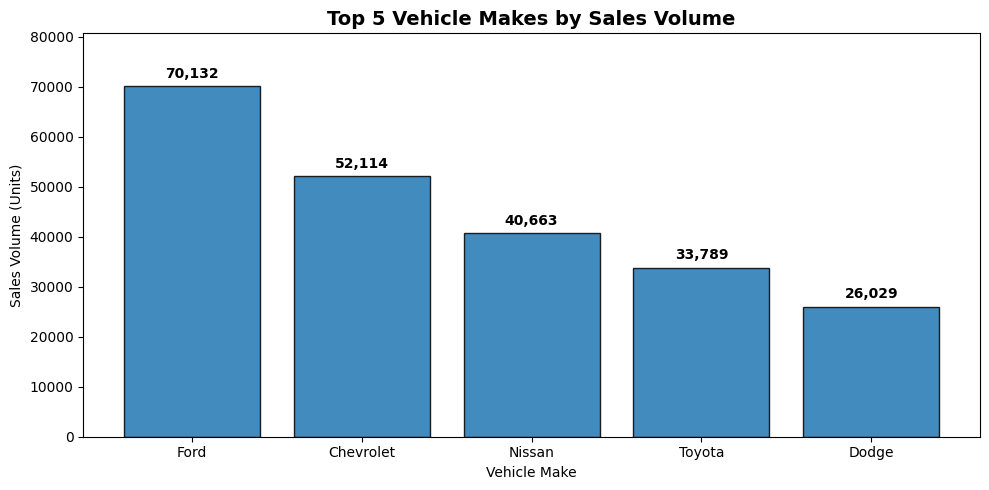

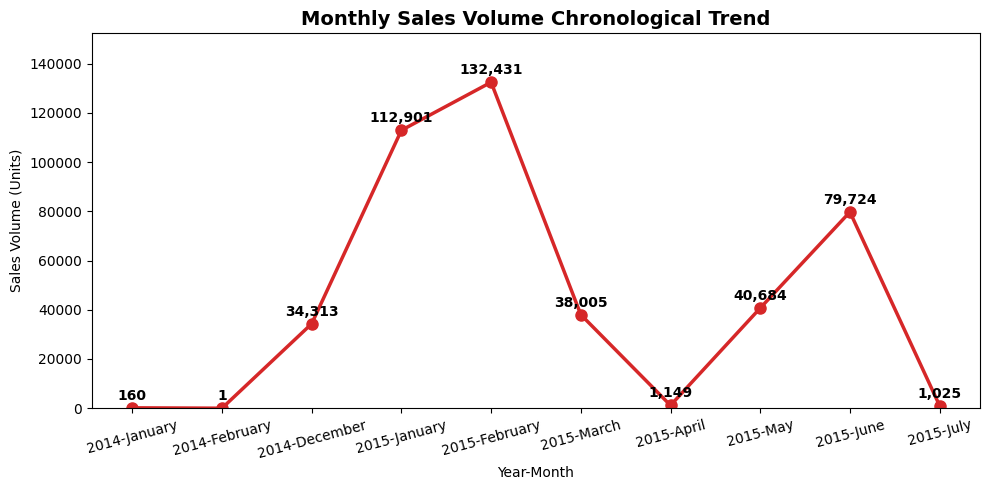

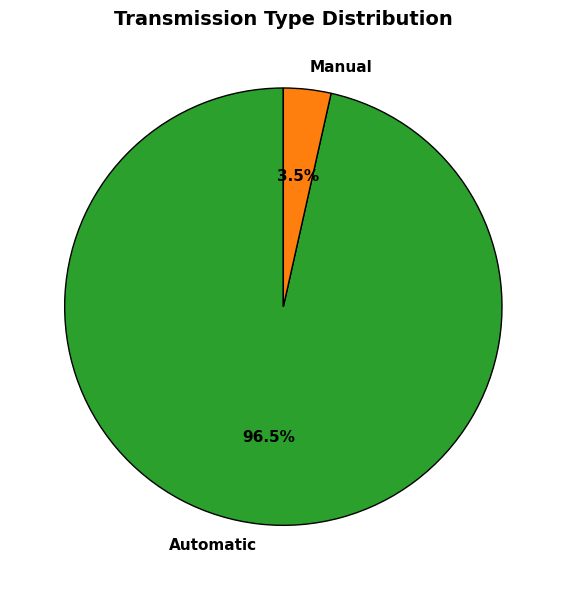

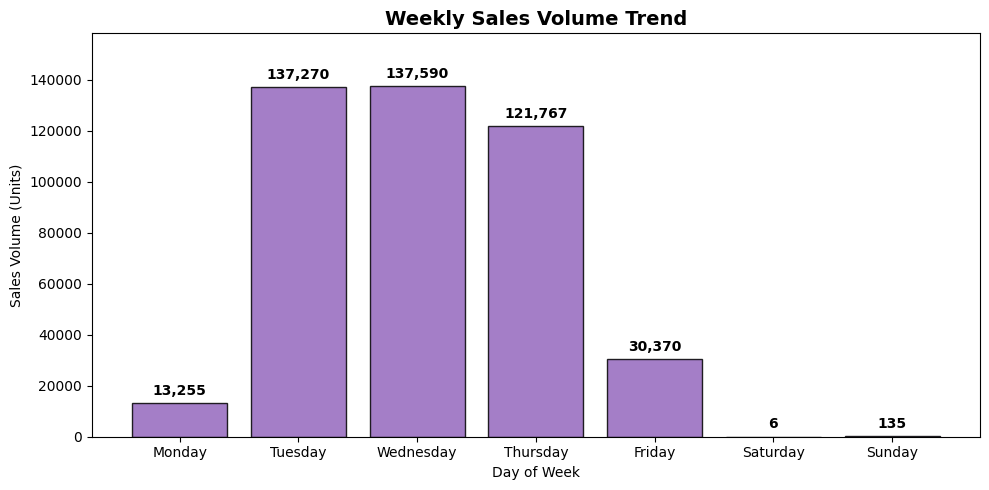

In [14]:
def render_matplotlib_dashboard():
    """Reads cleaned CSV data and plots 4 high-quality charts using Matplotlib."""
    records = load_cleaned_data()
    if not records:
        return
        
    # Aggregate 1: Top 5 Makes by Sales Volume
    make_counts = Counter(r['make'] for r in records)
    top_makes = make_counts.most_common(5)
    makes = [item[0] for item in top_makes]
    make_volumes = [item[1] for item in top_makes]
    
    # Aggregate 2: Monthly Sales Volumes
    monthly_counts = {}
    for r in records:
        dt = datetime.datetime.strptime(r['saledate'], "%Y-%m-%d")
        period = f"{dt.year}-{dt.strftime('%B')}"
        sort_key = (dt.year, dt.month, period)
        monthly_counts[sort_key] = monthly_counts.get(sort_key, 0) + 1
    sorted_monthly = sorted(monthly_counts.items(), key=lambda x: x[0])
    periods = [item[0][2] for item in sorted_monthly]
    monthly_volumes = [item[1] for item in sorted_monthly]
    
    # Aggregate 3: Transmission Volume Types
    trans_counts = Counter(r['transmission'] for r in records)
    trans_labels = [k.title() for k in trans_counts.keys()]
    trans_volumes = list(trans_counts.values())
    
    # Aggregate 4: Weekly Day Volume
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekly_counts = {day: 0 for day in weekday_order}
    for r in records:
        day = r['saleday']
        if day in weekly_counts:
            weekly_counts[day] += 1
    days = [day for day in weekday_order if weekly_counts[day] > 0]
    weekly_volumes = [weekly_counts[day] for day in days]
    
    # Chart 1: Bar Chart of Top Makes
    plt.figure(figsize=(10, 5))
    plt.bar(makes, make_volumes, color='#1f77b4', edgecolor='black', alpha=0.85)
    plt.title('Top 5 Vehicle Makes by Sales Volume', fontsize=14, weight='bold')
    plt.xlabel('Vehicle Make')
    plt.ylabel('Sales Volume (Units)')
    max_val1 = max(make_volumes) if make_volumes else 1
    plt.ylim(0, max_val1 * 1.15)
    offset1 = max_val1 * 0.015
    for idx, val in enumerate(make_volumes):
        plt.text(idx, val + offset1, "{:,}".format(val), ha='center', va='bottom', weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Chart 2: Line Chart of Monthly Volume Trends
    plt.figure(figsize=(10, 5))
    plt.plot(periods, monthly_volumes, marker='o', color='#d62728', linewidth=2.5, markersize=8)
    plt.title('Monthly Sales Volume Chronological Trend', fontsize=14, weight='bold')
    plt.xlabel('Year-Month')
    plt.ylabel('Sales Volume (Units)')
    plt.xticks(rotation=15)
    max_val2 = max(monthly_volumes) if monthly_volumes else 1
    plt.ylim(0, max_val2 * 1.15)
    offset2 = max_val2 * 0.015
    for idx, val in enumerate(monthly_volumes):
        plt.text(idx, val + offset2, "{:,}".format(val), ha='center', va='bottom', weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Chart 3: Pie Chart of Transmission Distributions
    plt.figure(figsize=(6, 6))
    plt.pie(trans_volumes, labels=trans_labels, autopct='%1.1f%%', colors=['#2ca02c', '#ff7f0e'], startangle=90,
                   textprops={'fontsize': 11, 'weight': 'bold'}, wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})
    plt.title('Transmission Type Distribution', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Chart 4: Bar Chart of Weekly Volume Trends
    plt.figure(figsize=(10, 5))
    plt.bar(days, weekly_volumes, color='#9467bd', edgecolor='black', alpha=0.85)
    plt.title('Weekly Sales Volume Trend', fontsize=14, weight='bold')
    plt.xlabel('Day of Week')
    plt.ylabel('Sales Volume (Units)')
    max_val4 = max(weekly_volumes) if weekly_volumes else 1
    plt.ylim(0, max_val4 * 1.15)
    offset4 = max_val4 * 0.015
    for idx, val in enumerate(weekly_volumes):
        plt.text(idx, val + offset4, "{:,}".format(val), ha='center', va='bottom', weight='bold')
    plt.tight_layout()
    plt.show()

render_matplotlib_dashboard()